# MoodNote-AI — Fine-tune ViSoBERT trên Google Colab

Pipeline phân loại cảm xúc tiếng Việt (7 classes) với **ViSoBERT** + UIT-VSMEC + ViGoEmotions.

| Bước | Cell | Mô tả |
|------|------|-------|
| Setup | 1 | GPU, Drive, Clone repo, Cài dependencies |
| Download | 2 | UIT-VSMEC + ViGoEmotions |
| Data Prep | 3 | Merge, Preprocess (word segmentation) |
| Augmentation | 4 | Random aug + Back-translation (Surprise, Anger) |
| Train | 5 | Curriculum Learning: Stage 1 → Stage 2 |
| Evaluate | 6 | Test predictions & classification report |

> **Trước khi chạy:** Runtime → Change runtime type → **T4 GPU**

In [2]:
# ── GPU Check ─────────────────────────────────────────────────────────────────
import torch
if not torch.cuda.is_available():
    raise RuntimeError("GPU not found. Runtime -> Change runtime type -> T4 GPU")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ── Mount Google Drive ─────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Clone Repo & Install ───────────────────────────────────────────────────────
import os, subprocess, sys

REPO_URL = 'https://github.com/ToanHuynh0201/MoodNote-AI.git'  # <- thay bang URL repo cua ban
REPO_DIR = '/content/MoodNote-AI'

if not os.path.exists(REPO_DIR):
    subprocess.run(['git', 'clone', REPO_URL, REPO_DIR], check=True)
else:
    subprocess.run(['git', '-C', REPO_DIR, 'pull', '--rebase'], check=True)

os.chdir(REPO_DIR)
subprocess.run(['pip', 'install', '-r', 'requirements.txt', '-q'], check=True)
subprocess.run(['pip', 'install', 'deep_translator', '-q'], check=True)
sys.path.insert(0, REPO_DIR)

# ── Paths ──────────────────────────────────────────────────────────────────────
CONFIG_DIR     = f'{REPO_DIR}/configs'
RAW_DIR        = f'{REPO_DIR}/data/raw'
PROCESSED_DIR  = f'{REPO_DIR}/data/processed'
DRIVE_DIR      = '/content/drive/MyDrive/MoodNote-AI'
CHECKPOINT_DIR = f'{DRIVE_DIR}/checkpoints'
BEST_MODEL_DIR = f'{DRIVE_DIR}/best_model'

for d in [RAW_DIR, PROCESSED_DIR, CHECKPOINT_DIR, BEST_MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

print("\nSetup hoan tat.")
print(f"  Repo    : {REPO_DIR}")
print(f"  Drive   : {DRIVE_DIR}")

GPU: Tesla T4
VRAM: 15.6 GB
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Setup hoan tat.
  Repo    : /content/MoodNote-AI
  Drive   : /content/drive/MyDrive/MoodNote-AI


In [3]:
import os
os.chdir(REPO_DIR)

# ── UIT-VSMEC ──────────────────────────────────────────────────────────────────
print("=" * 50)
print("Downloading UIT-VSMEC...")
from src.data.download_dataset import download_uit_vsmec
download_uit_vsmec(output_dir=RAW_DIR)

# ── ViGoEmotions (gated - can HF Token) ───────────────────────────────────────
# Truoc khi chay: Runtime -> Manage secrets -> them key HF_TOKEN
print("\n" + "=" * 50)
print("Downloading ViGoEmotions...")
from google.colab import userdata
from src.data.download_vigoemotions import download_vigoemotions
hf_token = userdata.get('HF_TOKEN')
# output_dir=RAW_DIR vi ham tu append /vigoemotions ben trong
download_vigoemotions(output_dir=RAW_DIR, token=hf_token)

print("\nDownload hoan tat.")

README.md: 0.00B [00:00, ?B/s]

train.json: 0.00B [00:00, ?B/s]

valid.json: 0.00B [00:00, ?B/s]

test.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/5548 [00:00<?, ? examples/s]

...

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/16531 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2066 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2067 [00:00<?, ? examples/s]

Dataset loaded successfully!

train: 16531 samples | columns: ['id', 'text', 'labels']
  Detected label format: list_column
  Saved to /content/MoodNote-AI/data/raw/vigoemotions/train.csv
  Sample row:
    text:   Xem mà ngẫm lại cuộc đời bản thân ta đã trải qua nhiều thứ ta rồi cũng sẽ lớn kí
    labels: ['embarrassment']

validation: 2066 samples | columns: ['id', 'text', 'labels']
  Detected label format: list_column
  Saved to /content/MoodNote-AI/data/raw/vigoemotions/validation.csv
  Sample row:
    text:   Buồn nốt tý dở thui nghen🥲🤩
    labels: ['admiration', 'amusement', 'optimism']

test: 2067 samples | columns: ['id', 'text', 'labels']
  Detected label format: list_column
  Saved to /content/MoodNote-AI/data/raw/vigoemotions/test.csv
  Sample row:
    text:   Ko coi p1 đi xem p2 thì đc ko ta Mai Huệ
    labels: ['fear']

Total samples: 20664
Avg labels per sample: 1.91

Top 15 most common fine-grained labels (across all splits):
  admiration          :  3569
  optimism      

In [4]:
import os
os.chdir(REPO_DIR)

from src.data.merge_datasets import main as merge_main
from src.data.preprocess import preprocess_dataset

# ── Merge VSMEC + ViGoEmotions ─────────────────────────────────────────────────
print("=" * 50)
print("Merging VSMEC + ViGoEmotions...")
merge_main(
    vsmec_dir=RAW_DIR,
    vigoemotions_dir=f'{RAW_DIR}/vigoemotions',
    output_dir=f'{REPO_DIR}/data/merged'
)

# ── Preprocess merged (train + val + test) ─────────────────────────────────────
print("\n" + "=" * 50)
print("Preprocessing merged dataset...")
preprocess_dataset(
    input_dir=f'{REPO_DIR}/data/merged',
    output_dir=PROCESSED_DIR,
    config_path=f'{CONFIG_DIR}/model_config.yaml'
)

# ── Preprocess VSMEC-only (dung cho Stage 1) ──────────────────────────────────
print("\n" + "=" * 50)
print("Preprocessing VSMEC-only (Stage 1)...")
VSMEC_ONLY_DIR = f'{PROCESSED_DIR}/vsmec_only'
preprocess_dataset(
    input_dir=RAW_DIR,
    output_dir=VSMEC_ONLY_DIR,
    config_path=f'{CONFIG_DIR}/model_config.yaml'
)

print("\nData prep hoan tat.")

Merging VSMEC + ViGoEmotions...
Starting dataset merge: UIT-VSMEC + ViGoEmotions
  VSMEC source:       /content/MoodNote-AI/data/raw
  ViGoEmotions source:/content/MoodNote-AI/data/raw/vigoemotions
  Output:             /content/MoodNote-AI/data/merged
  Minority classes:   ['Anger', 'Disgust', 'Fear', 'Other', 'Surprise']
  Max per class:      {'Anger': 700, 'Fear': 500, 'Disgust': 300, 'Surprise': 900, 'Other': 250}

  TRAIN SPLIT MERGE REPORT
  VSMEC samples:              5548
  ViGoEmotions input:        16531
  ViGoEmotions resolved:      5084
  ViGoEmotions skipped:      11447  (69.2%)
  ViGoEmotions filtered:      3078  (60.5% — non-minority classes)
  ViGoEmotions deduped:        365  (7.2% of resolved)
  ViGoEmotions added:         1440

  Skipped sample examples (first 10):
    labels=['anger', 'desire', 'annoyance']  text=bức ảnh xuất sắc ❤️
    labels=['desire', 'curiosity']  text=Vừa đẹp trai, vừa tài giỏi. Nhà mặt phố, bố làm to
    labels=['relief', 'realization']  text=

Segmenting train: 100%|██████████| 6988/6988 [00:03<00:00, 1901.75it/s]


Saved preprocessed data to /content/MoodNote-AI/data/processed/train.csv

Examples:

Original: Cho mình xin địa chỉ với
Segmented: Cho mình xin địa_chỉ với
Label: 3

Original: nguyễn thị hồng phấn cũng may tao không thấy cặp nao hêtd
Segmented: nguyễn thị hồng phấn cũng may tao không thấy cặp nao hêtd
Label: 1

Original: vàng tây có hít ko ta
Segmented: vàng_tây có hít ko ta
Label: 3

Processing validation split...
Loaded 686 samples
Using column 'Sentence' for text
Using column 'Emotion' for labels
Applying word segmentation...


Segmenting validation: 100%|██████████| 686/686 [00:00<00:00, 1431.53it/s]


Saved preprocessed data to /content/MoodNote-AI/data/processed/validation.csv

Examples:

Original: tính tao tao biết , chẳng có chuyện gì có thể làm tao phát điên cả
Segmented: tính tao tao biết , chẳng có chuyện gì có_thể làm tao phát điên cả
Label: 6

Original: lại là lào cai , tự hào quê mình quá :))
Segmented: lại là lào cai , tự_hào quê mình quá : ) )
Label: 0

Original: bị từ chối rồi
Segmented: bị từ_chối rồi
Label: 1

Processing test split...
Loaded 693 samples
Using column 'Sentence' for text
Using column 'Emotion' for labels
Applying word segmentation...


...

Saved preprocessed data to /content/MoodNote-AI/data/processed/vsmec_only/train.csv

Examples:

Original: cho mình xin bài nhạc tên là gì với ạ
Segmented: cho mình xin bài nhạc tên là gì với ạ
Label: 6

Original: cho đáng đời con quỷ . về nhà lôi con nhà mày ra mà đánh 😡
Segmented: cho đáng_đời con quỷ . về nhà lôi con nhà mày ra mà đánh 😡
Label: 4

Original: lo học đi . yêu đương lol gì hay lại thích học sinh học
Segmented: lo học đi . yêu_đương lol gì hay lại thích học_sinh_học
Label: 4

Processing validation split...
Loaded 686 samples
Using column 'Sentence' for text
Using column 'Emotion' for labels
Applying word segmentation...


Segmenting validation: 100%|██████████| 686/686 [00:00<00:00, 2222.22it/s]


Saved preprocessed data to /content/MoodNote-AI/data/processed/vsmec_only/validation.csv

Examples:

Original: tính tao tao biết , chẳng có chuyện gì có thể làm tao phát điên cả
Segmented: tính tao tao biết , chẳng có chuyện gì có_thể làm tao phát điên cả
Label: 6

Original: lại là lào cai , tự hào quê mình quá :))
Segmented: lại là lào cai , tự_hào quê mình quá : ) )
Label: 0

Original: bị từ chối rồi
Segmented: bị từ_chối rồi
Label: 1

Processing test split...
Loaded 693 samples
Using column 'Sentence' for text
Using column 'Emotion' for labels
Applying word segmentation...


Segmenting test: 100%|██████████| 693/693 [00:00<00:00, 2246.02it/s]

Saved preprocessed data to /content/MoodNote-AI/data/processed/vsmec_only/test.csv

Examples:

Original: người ta có bạn bè nhìn vui thật
Segmented: người_ta có bạn_bè nhìn vui thật
Label: 1

Original: cho nghỉ viêc mói đúng sao goi là kỷ luật
Segmented: cho nghỉ viêc mói đúng sao goi là kỷ_luật
Label: 5

Original: kinh vãi 😡
Segmented: kinh vãi 😡
Label: 4

✓ Preprocessing complete!

Data prep hoan tat.


In [5]:
import os, time
import pandas as pd
os.chdir(REPO_DIR)

from src.data.augment import augment_dataset, VietnameseAugmenter

AUGMENTED_TRAIN = f'{PROCESSED_DIR}/train_augmented.csv'

# ── Random Augmentation (Anger, Fear, Disgust, Surprise) ──────────────────────
print("=" * 50)
print("Random augmentation (deletion / swap / insertion)...")
augment_dataset(
    input_csv=f'{PROCESSED_DIR}/train.csv',
    output_csv=AUGMENTED_TRAIN,
    target_counts={2: 1800, 3: 1400, 4: 1300, 5: 1300},  # Surprise: 2000→1300 (tránh noise ratio quá cao)
    techniques=["deletion", "swap", "insertion"],
    seed=42
)

# ── Back-Translation helper ────────────────────────────────────────────────────
def run_backtranslation(df, label_id, n_samples, label_name):
    aug = VietnameseAugmenter(seed=42)
    samples = df[df['label'] == label_id].head(n_samples)
    bt_rows = []
    for i, (_, row) in enumerate(samples.iterrows()):
        bt = aug.back_translate(row['text'])
        if bt != row['text'] and bt.strip():
            bt_rows.append({'text': bt, 'label': label_id})
        time.sleep(0.1)
        if (i + 1) % 50 == 0:
            print(f"  {label_name}: {i + 1}/{n_samples} — {len(bt_rows)} valid")
    return bt_rows

augmented_df = pd.read_csv(AUGMENTED_TRAIN)

# ── Back-Translation: Surprise (class 5) ──────────────────────────────────────
print("\n" + "=" * 50)
print("Back-translation: Surprise (class 5, 400 samples)...")  # tăng từ 200→400 (back-translation bảo toàn ngữ nghĩa)
bt_surprise = run_backtranslation(augmented_df, label_id=5, n_samples=400, label_name="Surprise")
print(f"  Surprise: {len(bt_surprise)} paraphrases")

# ── Back-Translation: Anger (class 2) ─────────────────────────────────────────
print("\n" + "=" * 50)
print("Back-translation: Anger (class 2, 150 samples)...")
bt_anger = run_backtranslation(augmented_df, label_id=2, n_samples=150, label_name="Anger")
print(f"  Anger: {len(bt_anger)} paraphrases")

# ── Save ───────────────────────────────────────────────────────────────────────
all_bt = bt_surprise + bt_anger
if all_bt:
    bt_df = pd.DataFrame(all_bt)
    final_df = pd.concat([augmented_df, bt_df], ignore_index=True).sample(frac=1, random_state=42)
    final_df.to_csv(AUGMENTED_TRAIN, index=False)
    print(f"\nDataset sau augmentation: {len(final_df)} mau")
    print(final_df['label'].value_counts().sort_index().to_string())
else:
    print("\nKhong co BT paraphrase — giu nguyen random augmented dataset.")

Random augmentation (deletion / swap / insertion)...
Loaded 6988 samples from /content/MoodNote-AI/data/processed/train.csv

Current class distribution:
  Enjoyment    (class 0): 1558 → target 1558
  Sadness      (class 1):  947 → target  947
  Anger        (class 2):  444 → target 1800
  Fear         (class 3):  818 → target 1400
  Disgust      (class 4): 1371 → target 1300
  Surprise     (class 5):  801 → target 1300
  Other        (class 6): 1049 → target 1049

Augmenting Anger (class 2): 444 → 1800 (+1356)
  Generated 1356 augmented samples

Augmenting Fear (class 3): 818 → 1400 (+582)
  Generated 582 augmented samples

Disgust: already has 1371 >= 1300, skipping.

Augmenting Surprise (class 5): 801 → 1300 (+499)
  Generated 499 augmented samples

Augmented dataset: 6988 → 9425 samples
Saved to /content/MoodNote-AI/data/processed/train_augmented.csv

Final class distribution:
  Enjoyment    (class 0): 1558
  Sadness      (class 1):  947
  Anger        (class 2): 1800
  Fear        

INFO - Logger initialized. Log file: logs/model_utils_20260330_030908.log


INFO:model_utils:Logger initialized. Log file: logs/model_utils_20260330_030908.log


INFO - Logger initialized. Log file: logs/moodnote_20260330_030911.log


INFO:moodnote:Logger initialized. Log file: logs/moodnote_20260330_030911.log


INFO - Logger initialized. Log file: logs/moodnote_20260330_030911.log


...

INFO - Evaluating on test set...


INFO:moodnote:Evaluating on test set...



Evaluation Metrics

Overall Metrics:
  Accuracy:    0.5844
  F1-Macro:    0.5486
  F1-Weighted: 0.5810

Per-Class Metrics:
Emotion         Precision    Recall       F1-Score     Support   
------------------------------------------------------------
Enjoyment       0.6635       0.7150       0.6883       193       
Sadness         0.6612       0.6897       0.6751       116       
Anger           0.4324       0.4000       0.4156       40        
Fear            0.6458       0.6739       0.6596       46        
Disgust         0.5354       0.5152       0.5251       132       
Surprise        0.4167       0.4054       0.4110       37        
Other           0.4914       0.4419       0.4653       129       

Confusion matrix saved to /content/drive/MyDrive/MoodNote-AI/checkpoints/confusion_matrix.png
INFO - Model saved to /content/drive/MyDrive/MoodNote-AI/best_model


INFO:model_utils:Model saved to /content/drive/MyDrive/MoodNote-AI/best_model



TRAINING HOAN TAT
Accuracy   : 0.5844
F1-Macro   : 0.5486
F1-Weighted: 0.5810
Model da luu tai: /content/drive/MyDrive/MoodNote-AI/best_model


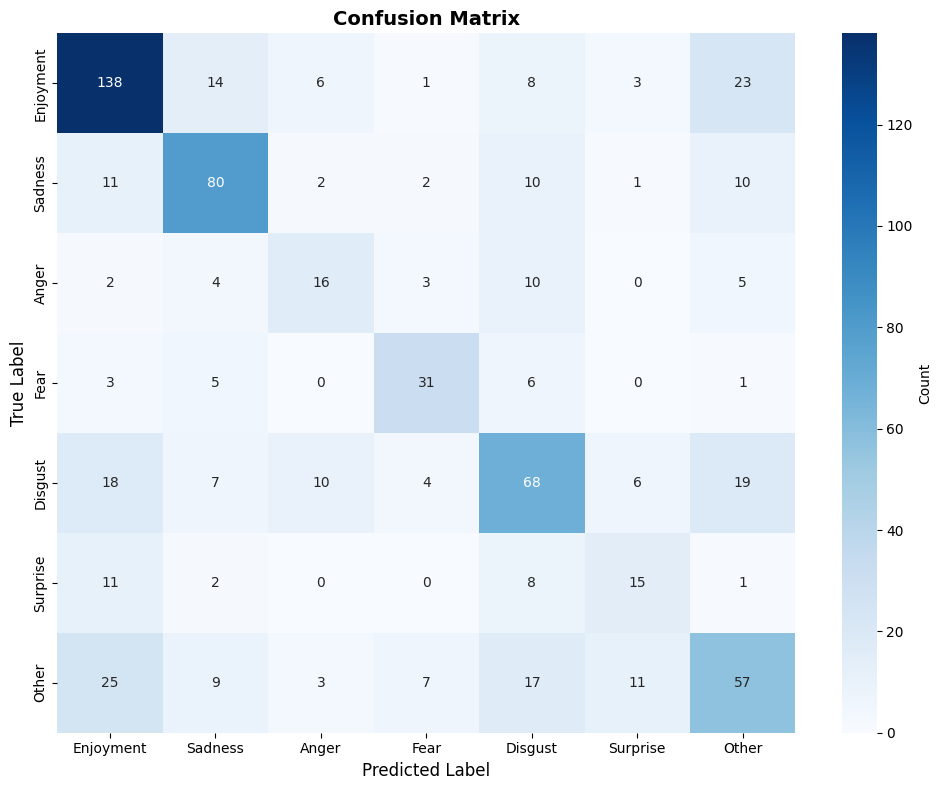

In [6]:
import os, torch, copy
import pandas as pd
os.chdir(REPO_DIR)

from src.data.dataset import EmotionDataset
from src.models.phobert_classifier import PhoBERTEmotionClassifier
from src.models.model_utils import save_model, get_device, print_model_summary
from src.training.trainer import train_model
from src.utils.config import load_all_configs
from src.utils.logger import setup_logger
from src.utils.metrics import compute_metrics, print_metrics, plot_confusion_matrix
import numpy as np
from pathlib import Path

logger = setup_logger(name='moodnote')

# Load configs
configs         = load_all_configs(CONFIG_DIR)
model_config    = configs['model']
training_config = configs['training']

logger.info(f"Model         : {model_config['model']['name']}")
logger.info(f"Epochs        : {training_config['training']['num_epochs']}")
logger.info(f"Batch size    : {training_config['training']['batch_size']}")
logger.info(f"LR            : {training_config['training']['learning_rate']}")
logger.info(f"Focal gamma   : {model_config['model'].get('focal_gamma', 2.0)}")

device = get_device()

model_name      = model_config['model']['name']
max_len         = model_config['model']['max_seq_length']
VSMEC_ONLY_DIR  = f'{PROCESSED_DIR}/vsmec_only'
AUGMENTED_TRAIN = f'{PROCESSED_DIR}/train_augmented.csv'
STAGE1_DIR      = f'{CHECKPOINT_DIR}/stage1'

# Smoke test: xac nhan dung model ViSoBERT
from transformers import AutoModel as _AM
_m = _AM.from_pretrained(model_name)
assert _m.config.hidden_size == 768, f"Expected hidden_size=768, got {_m.config.hidden_size}"
assert _m.config.num_hidden_layers == 12, f"Expected 12 layers, got {_m.config.num_hidden_layers}"
del _m
logger.info("Smoke test passed: hidden_size=768, num_hidden_layers=12")

# Datasets
train_dataset = EmotionDataset(AUGMENTED_TRAIN,                   tokenizer_name=model_name, max_length=max_len)
val_dataset   = EmotionDataset(f'{PROCESSED_DIR}/validation.csv', tokenizer_name=model_name, max_length=max_len)
test_dataset  = EmotionDataset(f'{PROCESSED_DIR}/test.csv',       tokenizer_name=model_name, max_length=max_len)
vsmec_train   = EmotionDataset(f'{VSMEC_ONLY_DIR}/train.csv',     tokenizer_name=model_name, max_length=max_len)

logger.info(f"Train (augmented): {len(train_dataset)}, VSMEC-only: {len(vsmec_train)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# Class weights
train_labels  = pd.read_csv(AUGMENTED_TRAIN)['label'].tolist()
class_counts  = np.bincount(train_labels, minlength=7).astype(float)
class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float32)
class_weights = class_weights / class_weights.sum() * 7
print("Class weights (tu augmented train):")
for i, w in enumerate(class_weights):
    print(f"  {model_config['emotion_labels'][i]:<12}: {w:.3f}")

# Model
model = PhoBERTEmotionClassifier(
    model_name=model_name,
    num_labels=model_config['model']['num_labels'],
    dropout=model_config['model']['dropout'],
    class_weights=class_weights,
    label_smoothing=model_config['model'].get('label_smoothing', 0.0),
    focal_gamma=model_config['model'].get('focal_gamma', 2.0)
)
model.to(device)
print_model_summary(model)

if torch.cuda.is_available():
    logger.info(f"GPU memory after model load: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

# ── Curriculum Stage 1: VSMEC-only (clean foundation) ─────────────────────────
print("\n" + "=" * 50)
print("Stage 1: VSMEC-only — 10 epochs (clean data, no R-Drop)")
print("=" * 50)

stage1_config = copy.deepcopy(training_config)
stage1_config['training']['num_epochs']    = 10
stage1_config['training']['warmup_ratio']  = 0.2
stage1_config['training']['learning_rate'] = 3e-5  # Stage 1: clean data, no R-Drop
stage1_config['training']['rdrop_alpha']   = 0.0

train_model(
    model=model,
    train_dataset=vsmec_train,
    eval_dataset=val_dataset,
    training_config=stage1_config,
    output_dir=STAGE1_DIR,
    use_wandb=False
)

# ── Curriculum Stage 2: Augmented merged + R-Drop ─────────────────────────────
print("\n" + "=" * 50)
print("Stage 2: Augmented merged data — 15 epochs (R-Drop alpha=1.0)")
print("=" * 50)

training_config['training']['rdrop_alpha'] = 1.0  # R-Drop (NeurIPS 2021) — giảm từ 4.0 tránh overwhelm CE loss
training_config['training']['num_epochs'] = 15   # giảm từ 20

trainer = train_model(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    training_config=training_config,
    output_dir=CHECKPOINT_DIR,
    use_wandb=training_config.get('wandb', {}).get('enabled', False)
)

# Evaluate on test set
logger.info("Evaluating on test set...")
predictions = trainer.predict(test_dataset)
detailed    = compute_metrics(predictions.predictions, predictions.label_ids)
print_metrics(detailed, model_config['emotion_labels'])

# Confusion matrix
plot_confusion_matrix(
    predictions.predictions, predictions.label_ids,
    emotion_labels=model_config['emotion_labels'],
    save_path=Path(CHECKPOINT_DIR) / 'confusion_matrix.png'
)

# Save
save_model(
    model=trainer.model,
    tokenizer=train_dataset.tokenizer,
    save_dir=BEST_MODEL_DIR,
    config={
        'model_config': model_config,
        'training_config': training_config,
        'test_results': {
            'accuracy':    detailed['accuracy'],
            'f1_macro':    detailed['f1_macro'],
            'f1_weighted': detailed['f1_weighted']
        }
    }
)

print("\n" + "=" * 50)
print("TRAINING HOAN TAT")
print("=" * 50)
print(f"Accuracy   : {detailed['accuracy']:.4f}")
print(f"F1-Macro   : {detailed['f1_macro']:.4f}")
print(f"F1-Weighted: {detailed['f1_weighted']:.4f}")
print(f"Model da luu tai: {BEST_MODEL_DIR}")

In [7]:
import os
os.chdir(REPO_DIR)

from src.inference.predictor import EmotionPredictor

# Files trong Drive
print("Files trong best_model:")
for f in sorted(os.listdir(BEST_MODEL_DIR)):
    size = os.path.getsize(f'{BEST_MODEL_DIR}/{f}') / 1024**2
    print(f"  {f:<30} {size:.1f} MB")

# Test predict
print("\nTest predict:")
predictor = EmotionPredictor(model_path=BEST_MODEL_DIR)

test_sentences = [
    "Hôm nay tôi rất vui vì được nghỉ học!",          # Enjoyment
    "Tôi buồn quá, không biết phải làm sao.",          # Sadness
    "Thật tức giận khi bị đối xử bất công.",           # Anger
    "Trời ơi, tin này làm tôi bất ngờ quá!",           # Surprise
    "Tôi sợ lắm, không dám đi một mình.",              # Fear
    "Thấy ghê quá, không thể chịu được.",              # Disgust
]

for sentence in test_sentences:
    result = predictor.predict(sentence)
    print(f"  Text      : {sentence}")
    print(f"  Emotion   : {result['emotion']}")
    print(f"  Confidence: {result['confidence']:.2%}")
    print()

INFO - Logger initialized. Log file: logs/predictor_20260330_033231.log


INFO:predictor:Logger initialized. Log file: logs/predictor_20260330_033231.log


Files trong best_model:
  added_tokens.json              0.0 MB
  bpe.codes                      1.1 MB
  config.yaml                    0.0 MB
  model.pt                       373.4 MB
  tokenizer.json                 0.7 MB
  tokenizer_config.json          0.0 MB
  vocab.txt                      0.9 MB

Test predict:
INFO - Loading model from /content/drive/MyDrive/MoodNote-AI/best_model...


INFO:predictor:Loading model from /content/drive/MyDrive/MoodNote-AI/best_model...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

INFO - Model loaded from /content/drive/MyDrive/MoodNote-AI/best_model


INFO:model_utils:Model loaded from /content/drive/MyDrive/MoodNote-AI/best_model


INFO - Predictor initialized successfully!


INFO:predictor:Predictor initialized successfully!


  Text      : Hôm nay tôi rất vui vì được nghỉ học!
  Emotion   : Enjoyment
  Confidence: 37.71%

  Text      : Tôi buồn quá, không biết phải làm sao.
  Emotion   : Sadness
  Confidence: 98.09%

  Text      : Thật tức giận khi bị đối xử bất công.
  Emotion   : Surprise
  Confidence: 47.91%

  Text      : Trời ơi, tin này làm tôi bất ngờ quá!
  Emotion   : Surprise
  Confidence: 90.46%

  Text      : Tôi sợ lắm, không dám đi một mình.
  Emotion   : Fear
  Confidence: 99.39%

  Text      : Thấy ghê quá, không thể chịu được.
  Emotion   : Surprise
  Confidence: 42.43%

